SGD_0.01 Test Accuracy: 0.79
SGD_0.1 Test Accuracy: 0.955
Adam_0.01 Test Accuracy: 0.95
RMSProp_0.01 Test Accuracy: 0.92


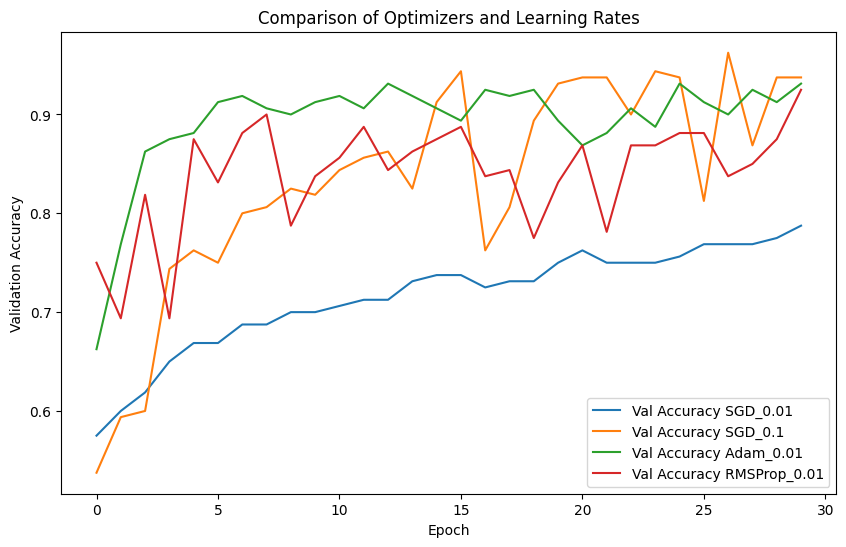

In [13]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

np.random.seed(42)
X = np.random.rand(1000, 10)
y = (X.sum(axis=1) > 5).astype(int)  # مجموع > 5 → 1، وگرنه 0

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

input_dim = X.shape[1]

def build_model():
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

optimizers = {
    "SGD_0.01": keras.optimizers.SGD(learning_rate=0.01),
    "SGD_0.1": keras.optimizers.SGD(learning_rate=0.1),
    "Adam_0.01": keras.optimizers.Adam(learning_rate=0.01),
    "RMSProp_0.01": keras.optimizers.RMSprop(learning_rate=0.01)
}

histories = {}

for name, opt in optimizers.items():
    model = build_model()
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=30, batch_size=32,
                        validation_split=0.2, verbose=0)
    histories[name] = history
    print(f"{name} Test Accuracy:", round(model.evaluate(X_test, y_test, verbose=0)[1], 3))


plt.figure(figsize=(10,6))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=f'Val Accuracy {name}')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Comparison of Optimizers and Learning Rates')
plt.show()
